# **Classification Project**

### About the Dataset:
- The sinking of the Titanic is one of the most infamous shipwrecks in history.

- On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately,  there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

- While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

- Objective: 
    - Build a **predictive model** that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

In [265]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [266]:
df = pd.read_csv('/home/vinayakgaur07/Aiml Course/ALL Datasets/kaggle_Titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### EDA:

In [267]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age, Cabin and Embarked Columns have **NULLS**
- Therefore:
    - We drop Cabin column (almost 77% enteries are Nulls) 
    - Use Imputation for Age 
    - Also drop Nulls in Embarked column as they are just 0.22% of the data

In [268]:
df.duplicated().sum()

0

NO Duplicates

In [269]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [270]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [271]:
df=df.drop(['PassengerId', 'Name', 'Cabin', 'Ticket'], axis=1)

### Imputation:
- We are going to impute 'Age' feature with **Median** as strategy

In [272]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df['Age'] = imputer.fit_transform(df[['Age']])

To drop all nulls automatically:

In [273]:
df=df.dropna()

Rechecking for any Null value: 

In [274]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [275]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


Categorical Features are:

In [276]:
df['Pclass'].unique()

array([3, 1, 2])

In [277]:
df['Parch'].unique()

array([0, 1, 2, 5, 3, 4, 6])

In [278]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [279]:
df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

Therefore, All Categorical Columns:
- Pclass
- Sex
- Parch
- Embarked

Checking Catgeorical Columns like (Embarked, Sex, Parch, Pclass):

In [280]:
df.groupby('SibSp')[['Survived']].agg(['mean', 'std'])

Survived          
           mean       std
SibSp                    
0      0.343234  0.475181
1      0.535885  0.499908
2      0.464286  0.507875
3      0.250000  0.447214
4      0.166667  0.383482
5      0.000000  0.000000
8      0.000000  0.000000

As values vary, we can say that SibSp is a Useful feature 

In [281]:
df.groupby('Embarked')[['Survived']].agg(['mean', 'std'])

Survived          
              mean       std
Embarked                    
C         0.553571  0.498608
Q         0.389610  0.490860
S         0.336957  0.473037

The closeness of values of mean and std shows that Embarked is NOT a useful feature for predicting Survived

In [282]:
df.groupby('Sex')[['Survived']].agg(['mean', 'std'])

Survived          
            mean       std
Sex                       
female  0.740385  0.439128
male    0.188908  0.391775

As the value vary from eachother we can say that Sex is a Useful feature for predicting Survived 

In [283]:
df.groupby('Parch')[['Survived']].agg(['mean', 'std'])

Survived          
           mean       std
Parch                    
0      0.341716  0.474636
1      0.550847  0.499529
2      0.500000  0.503155
3      0.600000  0.547723
4      0.000000  0.000000
5      0.200000  0.447214
6      0.000000       NaN

Therefore, Parch is not a Useful feature

In [284]:
df.groupby('Pclass')[['Survived']].agg(['mean', 'std'])

Survived          
            mean       std
Pclass                    
1       0.626168  0.484954
2       0.472826  0.500623
3       0.242363  0.428949

As the values vary, we can say that Pclass is a Useful feature

Therefore, finally:
- Pclass --> Useful
- Sex --> Useful
- SibSp --> Useful
- Parch --> Not Useful
- Embarked --> Not Useful

Visualizing Relationships:

<Axes: xlabel='Survived', ylabel='Sex'>

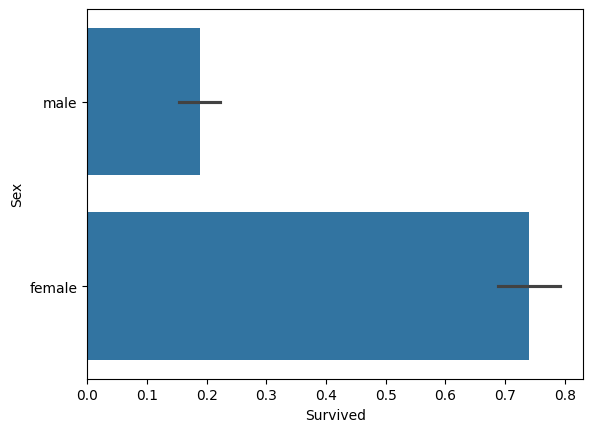

In [285]:
sns.barplot(data=df, x='Survived', y='Sex')

So, more Females survived than Males

<Axes: xlabel='Survived', ylabel='Age'>

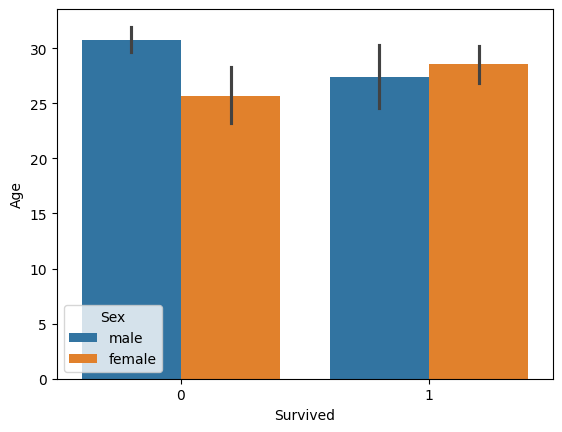

In [286]:
sns.barplot(data=df, x='Survived', y='Age', hue='Sex')

This Chart clearly states that, Women & Chidren were given more priority and that is why they survived more in number as compared to Men

Checking relationship between Pclass and Survived:

<Axes: xlabel='Survived', ylabel='Pclass'>

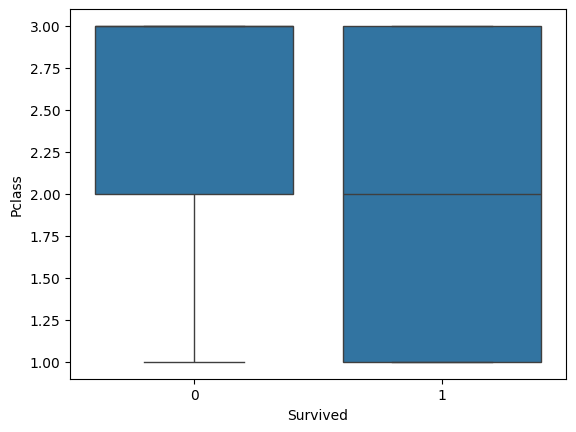

In [287]:
sns.boxplot(data=df, x='Survived', y='Pclass')

Outlier Treatment:

In [288]:
df = df[df['SibSp'] <= 2]

<Axes: xlabel='Survived', ylabel='SibSp'>

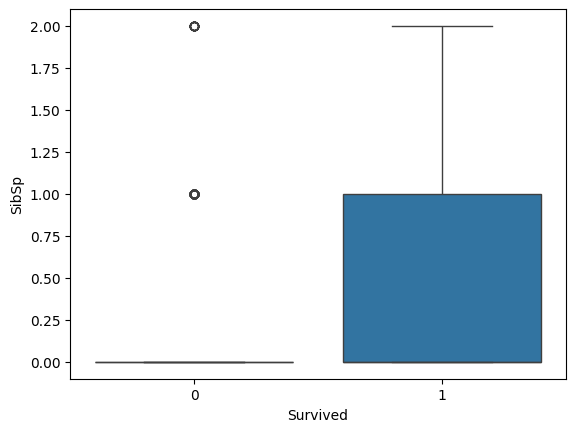

In [289]:
sns.boxplot(data=df, x='Survived', y='SibSp')

### Encoding:
- Sex: Label Encoding as there are only 2 enteries in it 

In [290]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


Label Encoding:

In [291]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

/tmp/ipykernel_12942/2923248532.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


Dropping the useless categorical column:

In [292]:
df = df.drop(['Embarked'], axis=1)

Building a Correlation Matrix:

In [293]:
corr_matrix = df.corr()
corr_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
Survived,1.000000,-0.321239,0.561686,-0.114887,0.152266,0.136623,0.269370
Pclass,-0.321239,1.000000,-0.137333,-0.312713,-0.114062,-0.036306,-0.563012
Sex,0.561686,-0.137333,1.000000,-0.092519,0.190410,0.255614,0.184909
Age,-0.114887,-0.312713,-0.092519,1.000000,-0.080518,-0.086055,0.115873
SibSp,0.152266,-0.114062,0.190410,-0.080518,1.000000,0.258797,0.178412
Parch,0.136623,-0.036306,0.255614,-0.086055,0.258797,1.000000,0.193220
Fare,0.269370,-0.563012,0.184909,0.115873,0.178412,0.193220,1.000000


Building a HeatMap:

<Axes: >

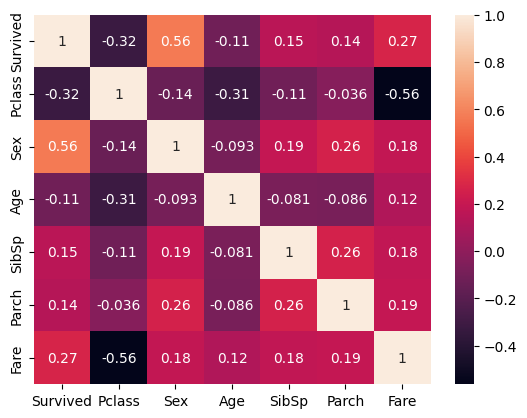

In [294]:
sns.heatmap(corr_matrix, annot=True)

Useful Features to Predict Survivors are:
- Sex
- Age
- Pclass
- Fare

In [296]:
X = df.drop(['Survived', 'SibSp', 'Parch'], axis=1)
y = df['Survived']

### Building the Model:

In [306]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [298]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling Data:

In [299]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()

X_train = SS.fit_transform(X_train)
X_test = SS.transform(X_test)

- We use fit_transform on X_train so we can fit the data on X_train and then transform the data 
- But we use only transform on X_test as we want to transform the data but use the fit of X_train

Logistic Regression:

In [307]:
lg = LogisticRegression()

lg_model = lg.fit(X_train, y_train)
lg_pred = lg.predict(X_test)
lg_acc = accuracy_score(y_test, lg_pred)
lg_cr = classification_report(y_test, lg_pred)

print(lg_acc)
print(lg_cr)

0.8224852071005917
              precision    recall  f1-score   support

           0       0.83      0.87      0.85        97
           1       0.81      0.76      0.79        72

    accuracy                           0.82       169
   macro avg       0.82      0.81      0.82       169
weighted avg       0.82      0.82      0.82       169



Random Forest Classifier:

In [308]:
rfc = RandomForestClassifier()

rfc_model = rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)
rfc_acc = accuracy_score(y_test, rfc_pred)
rfc_cr = classification_report(y_test, rfc_pred)

print(rfc_acc)
print(rfc_cr)

0.8402366863905325
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        97
           1       0.89      0.71      0.79        72

    accuracy                           0.84       169
   macro avg       0.85      0.82      0.83       169
weighted avg       0.85      0.84      0.84       169



Building Confusion Matrix:
- Accuracy can sometimes mislead therefore confusion matrix is used to visualize performance of the model 

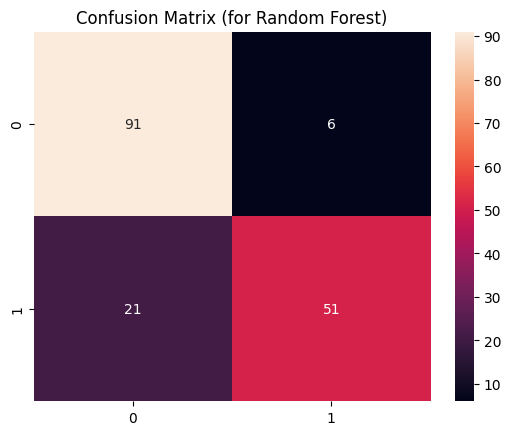

In [315]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, rfc_pred), annot=True)
plt.title('Confusion Matrix (for Random Forest)')
plt.show()

- **True Negatives**: Passengers correctly predicted as Not Survived (0.91 x 105 = **96**)
- **False Positives**: Passengers incorrectly predicted as Survived (105 - 96 = **9**)
- **False Negatives**: Survivors incorrectly predicted as Not Survived (0.77 x 66 = **51**)
- **True Positives**: Passengers correctly predicted as Survived (66 - 51 = **15**)

## Result

In [309]:
result = {
    'Model': ['Logistic Regression', 'Random Forest Regression'],
    'Accuracy Score':[lg_acc, rfc_acc]
}
result_df = pd.DataFrame(result)
result_df

,Model,Accuracy Score
0,Logistic Regression,0.822485
1,Random Forest Regression,0.840237


- **RandomForestClassifier** performed better with a score of **0.840(~84%)** accuracy in predicting Survivability of passengers 
- Although, accuracy score for Logistic Regression was close to Random Forest Accuracy Score standing at **0.822(82%)** which suggests that their exists some Non-Linearity in dataset due to which Random Forest Classifier performed better